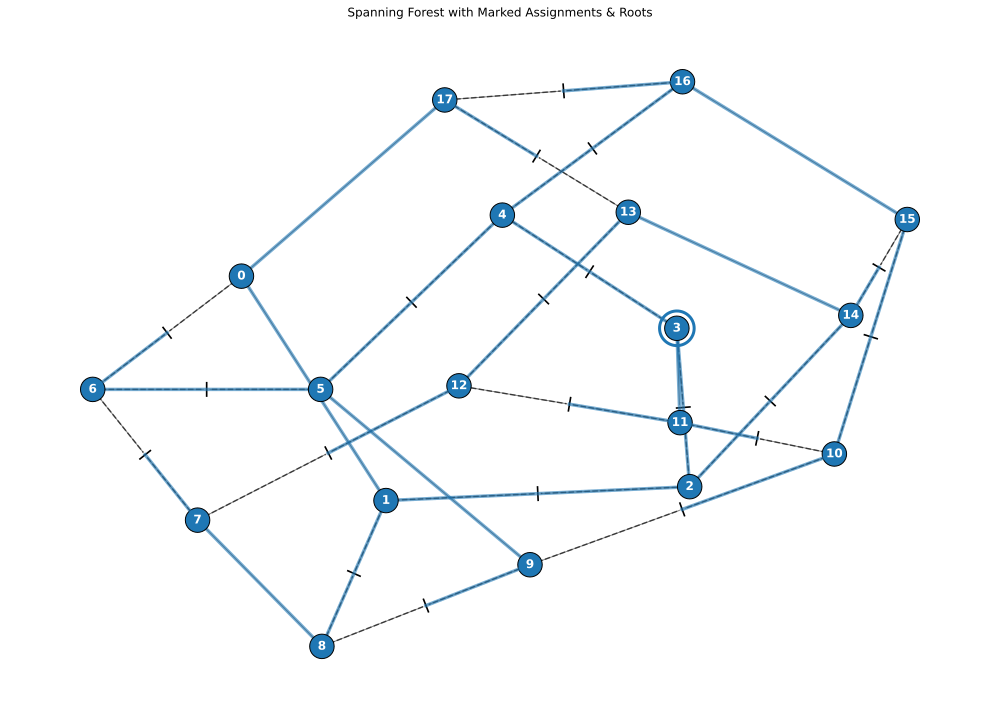

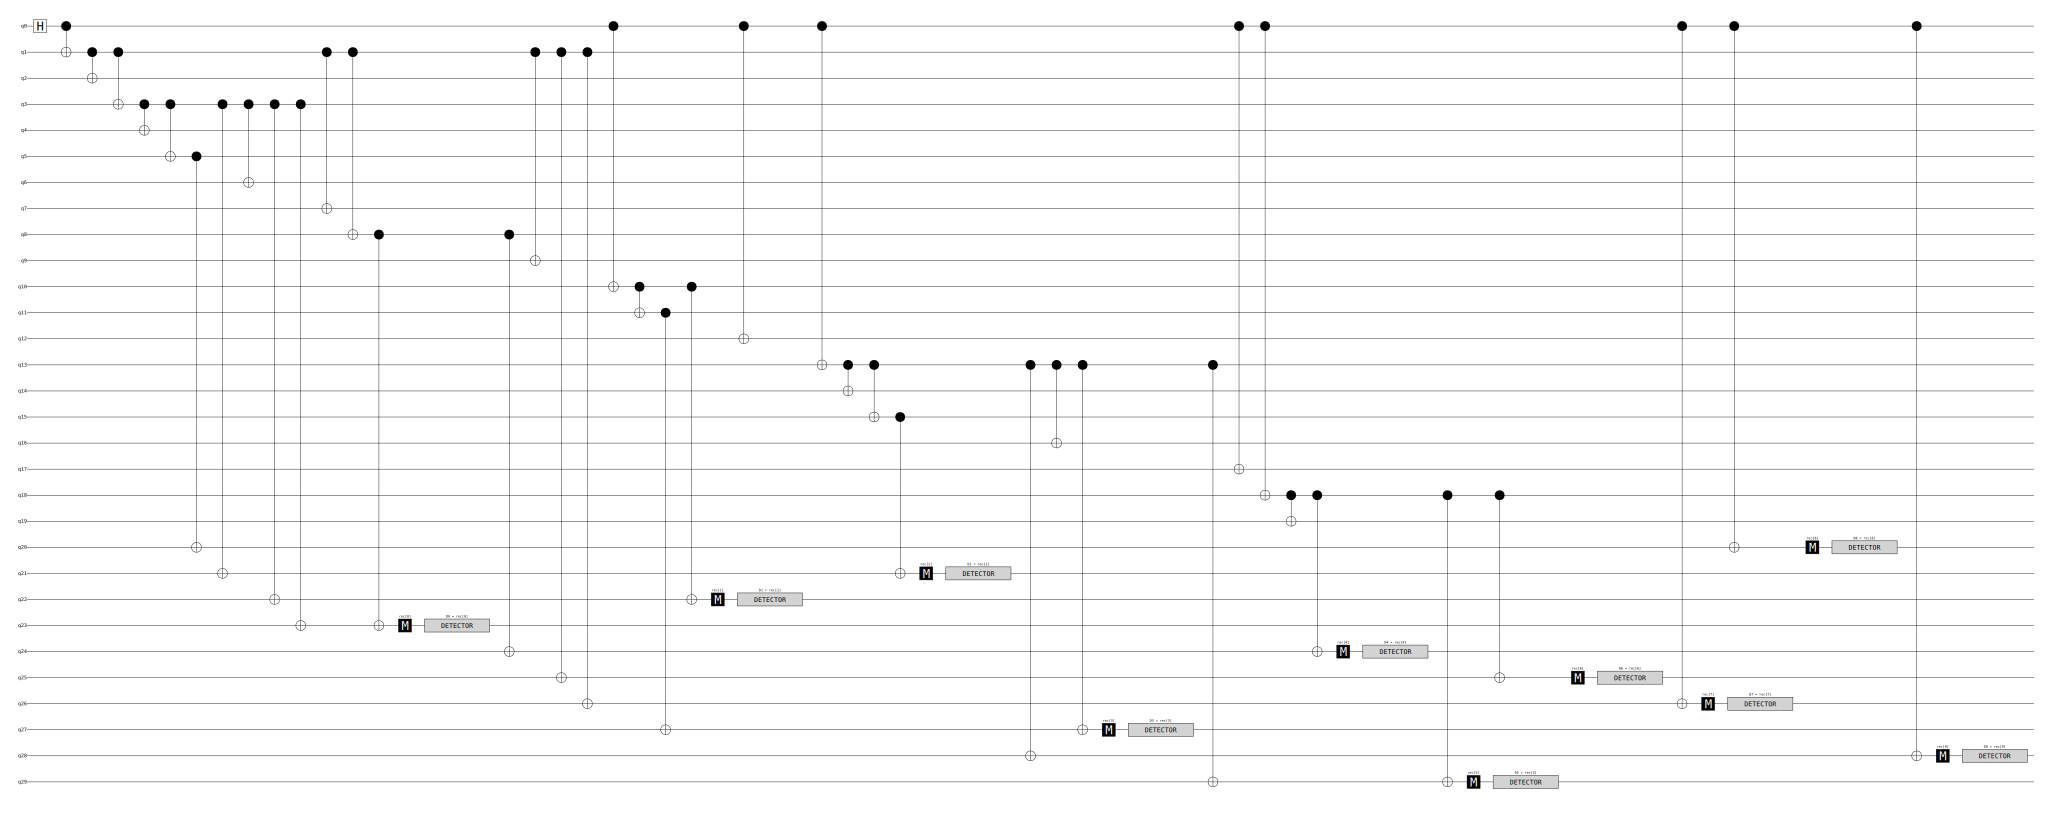

In [4]:
from spidercat.circuit_extraction import extract_circuit_rooted
import stim

from spidercat import markings
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet, ed

n, t, p = 20, 4, 1
grf, forest, M, matchings = load_solution_triplet(n, t, 1)
roots = find_min_height_roots(forest)

matchings = match_forest_leaves_to_marked_edges(forest, M)
roots = find_min_height_roots(forest)
draw_spanning_forest_solution(grf, forest, M, matchings, roots)

circ = extract_circuit_rooted(grf, forest, roots, M, matchings, verbose=False)
circ.diagram('timeline-svg')

In [5]:
from spidercat.benchmark import benchmark_circuit

og = benchmark_circuit(circ, n, num_samples=5_000_000, p=0.05)

Stats for 20-cat (p=0.05): {0: 0.5859255435003935, 1: 0.3165327374501296, 2: 0.08174214389213148, 3: 0.01370689009659456, 4: 0.0018404593660464805, 5: 0.0002009923504676028, 6: 2.890086085155073e-05, 7: 1.0509403946018447e-05, 8: 6.568377466261529e-06, 9: 1.3136754932523059e-06, 10: 3.941026479756917e-06}


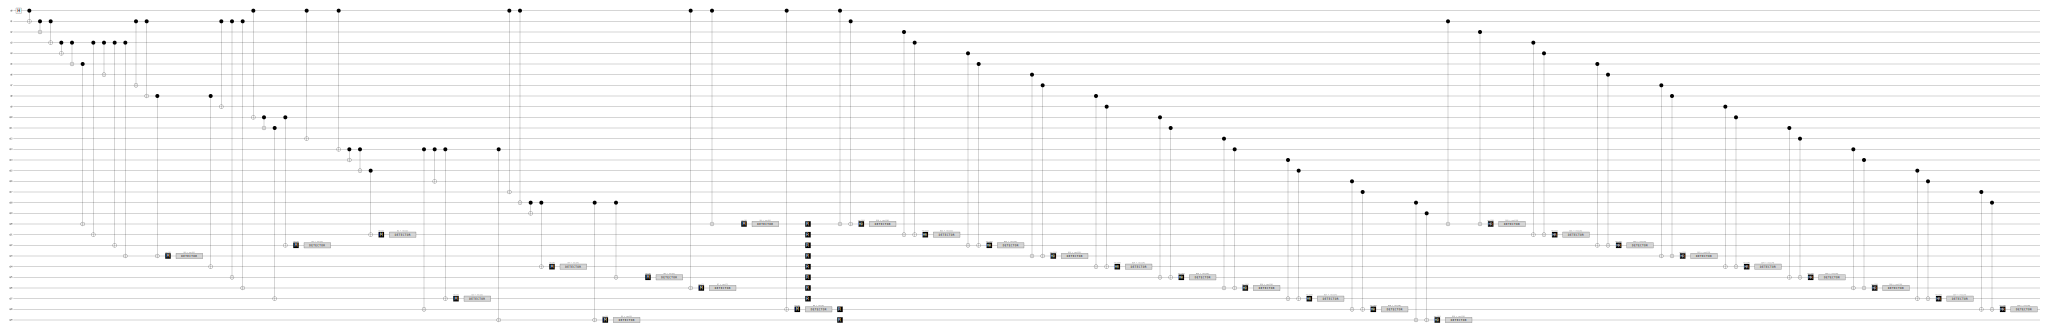

In [6]:
circ.append("R", range(n, n + n // 2))
for i in range(0, n, 2):
    circ.append("CX", [i, n + i // 2, i + 1, n + i // 2])
    circ.append("MR", n + i // 2)
    circ.append("DETECTOR", [stim.target_rec(-1)])
for i in range(1, n - 1, 2):
    circ.append("CX", [i, n + i // 2, i + 1, n + i // 2])
    circ.append("MR", n + i // 2)
    circ.append("DETECTOR", [stim.target_rec(-1)])
circ.diagram('timeline-svg')


In [7]:
new = benchmark_circuit(circ, n, num_samples=5_000_000, p=0.05)

Stats for 20-cat (p=0.05): {0: 0.7231764061858492, 1: 0.23078896948131927, 2: 0.04026960448884631, 3: 0.0052518133296838646, 4: 0.00047899274668126453, 5: 3.421376762009033e-05}


In [8]:
for i in range(max(*new.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.2%}  \t vs.\t New: {new.get(i, 0):.2%}")

Probability of 0 faults:	 Original 58.59%  	 vs.	 New: 72.32%
Probability of 1 faults:	 Original 31.65%  	 vs.	 New: 23.08%
Probability of 2 faults:	 Original 8.17%  	 vs.	 New: 4.03%
Probability of 3 faults:	 Original 1.37%  	 vs.	 New: 0.53%
Probability of 4 faults:	 Original 0.18%  	 vs.	 New: 0.05%
Probability of 5 faults:	 Original 0.02%  	 vs.	 New: 0.00%
Probability of 6 faults:	 Original 0.00%  	 vs.	 New: 0.00%
Probability of 7 faults:	 Original 0.00%  	 vs.	 New: 0.00%
Probability of 8 faults:	 Original 0.00%  	 vs.	 New: 0.00%
Probability of 9 faults:	 Original 0.00%  	 vs.	 New: 0.00%
